# 04 — Visualisations & interprétation biologique

**Objectif :** synthétiser visuellement les résultats différentiels et les confronter à la biologie connue de la maladie d'Alzheimer.

Trois visualisations de référence, plus l'interprétation :
1. **Volcano plot** — ampleur (log2FC) vs significativité, vue d'ensemble des gènes différentiels.
2. **Heatmap** — profils d'expression des top gènes différentiels + signature Alzheimer canonique.
3. **PCA** — les échantillons se séparent-ils spontanément par groupe ?
4. **Interprétation** — retrouve-t-on la signature Alzheimer attendue ? Comparaison à la littérature.

Les figures sont exportées en haute résolution dans `results/figures/` pour le README.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import plotting as pl

sns.set_theme(style="whitegrid", context="notebook")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
FIG_DIR = PROJECT_ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
DPI = 200  # haute résolution pour le README

# Résultats différentiels (notebook 03) + matrice gènes + métadonnées
results = pd.read_csv(TABLES_DIR / "de_results_entorhinal.csv", index_col=0)
genes = pd.read_parquet(PROCESSED_DIR / "ec_expr_gene_level.parquet")
meta = pd.read_csv(PROCESSED_DIR / "ec_metadata.csv", index_col=0)

print(f"{len(results)} gènes | {genes.shape[1]} échantillons "
      f"({meta['group'].value_counts().to_dict()})")
print("Signature canonique suivie :", pl.CANONICAL_AD_GENES)

10571 gènes | 23 échantillons ({'Control': 13, 'AD': 10})
Signature canonique suivie : ['GFAP', 'SST', 'GABRA1', 'NEFL', 'CALB1', 'VGF', 'RTN3']


## 1. Volcano plot

Chaque point = un gène. En abscisse son log2 fold-change (à droite = surexprimé chez AD), en ordonnée sa significativité (−log10 p-value, plus haut = plus significatif). Les lignes pointillées marquent les seuils (FDR < 5 %, |log2FC| ≥ 1). Les gènes de la **signature Alzheimer canonique** sont entourés et nommés.

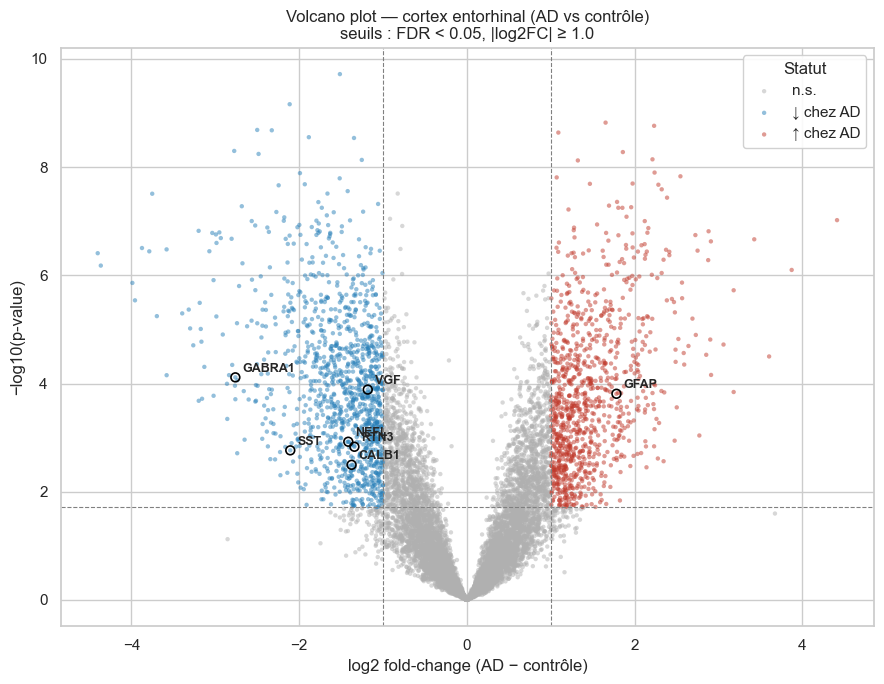

In [2]:
ax = pl.volcano_plot(results, alpha=0.05, lfc_threshold=1.0,
                     highlight_genes=pl.CANONICAL_AD_GENES)
plt.tight_layout()
plt.savefig(FIG_DIR / "volcano_entorhinal.png", dpi=DPI, bbox_inches="tight")
plt.show()

## 2. Heatmap des top gènes + signature canonique

Profils d'expression (z-score par gène) des gènes les plus différentiels, complétés par les gènes de la signature Alzheimer (en rouge gras). Le clustering regroupe échantillons et gènes par similarité ; la barre de couleur en haut indique le groupe. On s'attend à voir les deux groupes se séparer en blocs cohérents.

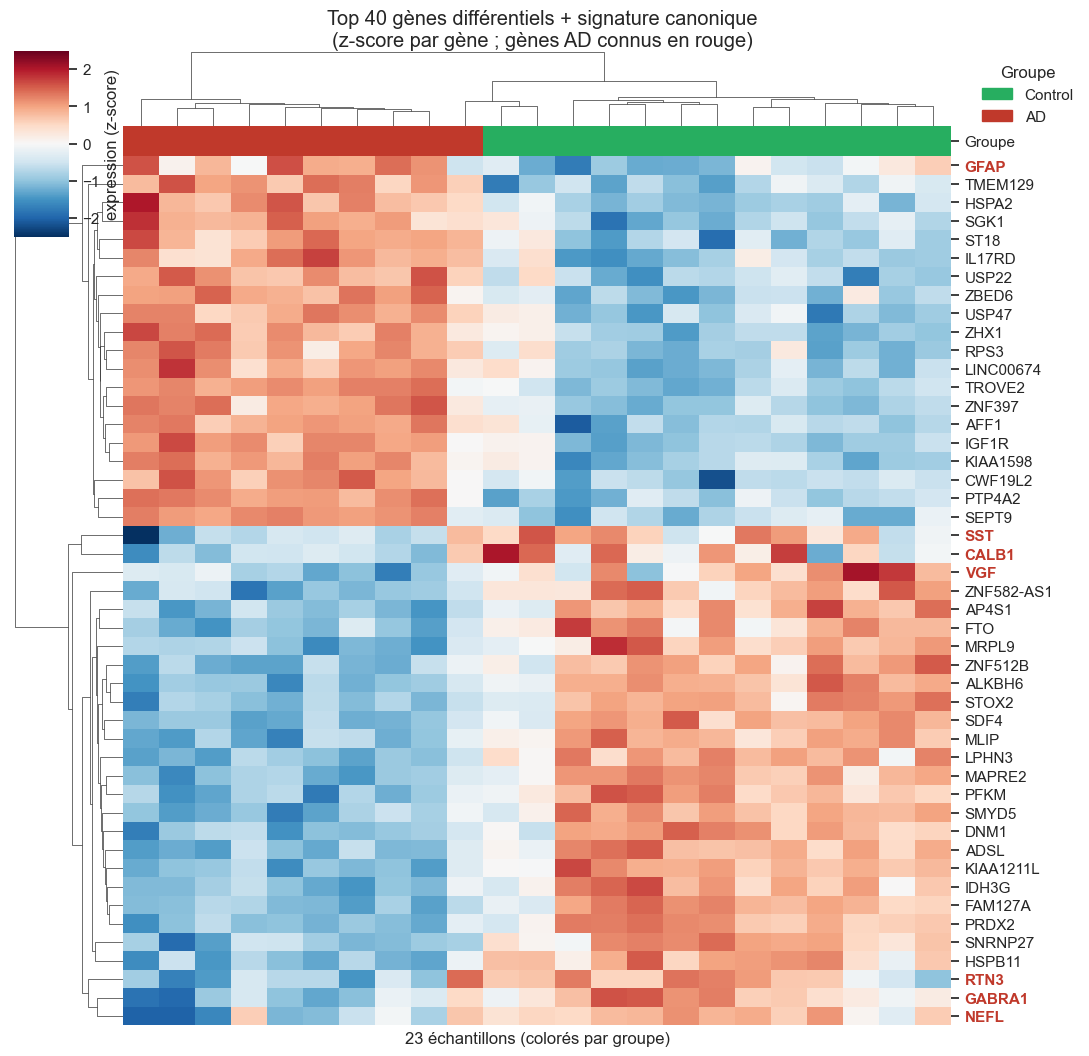

In [3]:
g = pl.top_genes_heatmap(genes, results, meta, n_top=40,
                         highlight_genes=pl.CANONICAL_AD_GENES)
g.savefig(FIG_DIR / "heatmap_top_genes.png", dpi=DPI, bbox_inches="tight")
plt.show()

## 3. PCA des échantillons

Réduction de dimension sur les 2 000 gènes les plus variables (standardisés). Si la biologie domine, les deux premières composantes doivent séparer AD et contrôles **sans** qu'on ait utilisé l'étiquette de groupe — une validation non supervisée du signal.

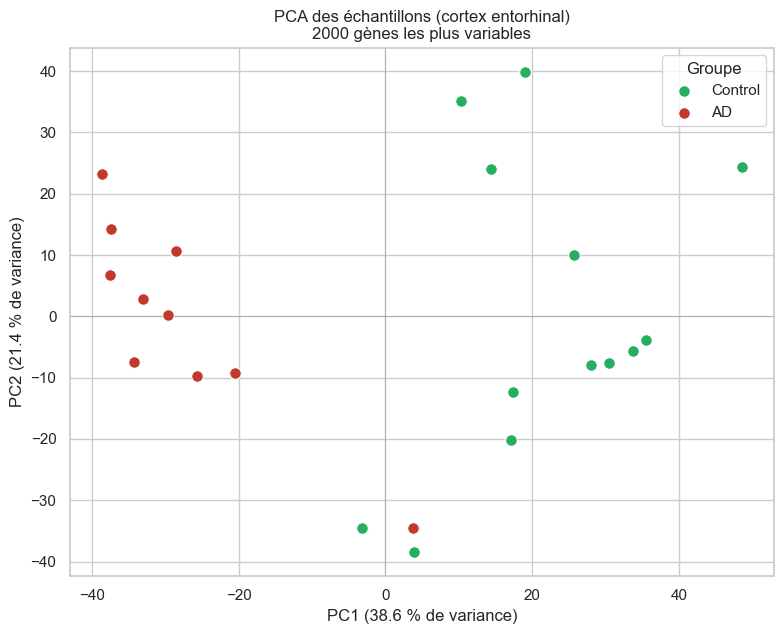

Variance expliquée — PC1 : 38.6 %  |  PC2 : 21.4 %


In [4]:
ax, scores, var_ratio = pl.pca_plot(genes, meta, n_top_var=2000)
plt.tight_layout()
plt.savefig(FIG_DIR / "pca_samples.png", dpi=DPI, bbox_inches="tight")
plt.show()

print(f"Variance expliquée — PC1 : {100*var_ratio[0]:.1f} %  |  PC2 : {100*var_ratio[1]:.1f} %")

## 4. Interprétation biologique

On confronte nos résultats à des gènes **connus** de la maladie d'Alzheimer. Deux familles attendues :
- des marqueurs **gliaux / inflammatoires**, attendus à la hausse (réaction astrocytaire) ;
- des marqueurs **neuronaux / synaptiques**, attendus à la baisse (perte neuronale et dysfonction synaptique).

On inclut aussi volontairement des gènes « célèbres » de l'AD (*APP, MAPT, PSEN1, APOE*) pour illustrer un point important.

In [5]:
# Panel de gènes AD connus, regroupés par catégorie biologique attendue
known_panel = {
    "GFAP": "glial/inflammatoire (↑ attendu)",
    "CD44": "glial/inflammatoire (↑ attendu)",
    "SPP1": "glial/inflammatoire (↑ attendu)",
    "SST": "neuronal/synaptique (↓ attendu)",
    "GABRA1": "neuronal/synaptique (↓ attendu)",
    "NEFL": "neuronal/synaptique (↓ attendu)",
    "CALB1": "neuronal/synaptique (↓ attendu)",
    "VGF": "neuronal/synaptique (↓ attendu)",
    "RTN3": "neuronal/synaptique (↓ attendu)",
    "SYT1": "neuronal/synaptique (↓ attendu)",
    "APP": "gène 'célèbre' AD (régulation post-traductionnelle)",
    "MAPT": "gène 'célèbre' AD (régulation post-traductionnelle)",
    "PSEN1": "gène 'célèbre' AD (régulation post-traductionnelle)",
    "APOE": "gène 'célèbre' AD (régulation post-traductionnelle)",
}
panel = results.reindex([g for g in known_panel if g in results.index])
panel = panel[["log2FC", "p_value", "p_adj"]].round(4)
panel["catégorie"] = [known_panel[g] for g in panel.index]
panel["significatif (FDR<0.05)"] = np.where(panel["p_adj"] < 0.05, "oui", "non")
panel.sort_values("log2FC")

,log2FC,p_value,p_adj,catégorie,significatif (FDR<0.05)
gene,,,,,
GABRA1,-2.7616,0.0001,0.0009,neuronal/synaptique (↓ attendu),oui
SST,-2.1068,0.0017,0.0078,neuronal/synaptique (↓ attendu),oui
NEFL,-1.4149,0.0012,0.0059,neuronal/synaptique (↓ attendu),oui
CALB1,-1.3758,0.0032,0.0125,neuronal/synaptique (↓ attendu),oui
RTN3,-1.3421,0.0015,0.0069,neuronal/synaptique (↓ attendu),oui
VGF,-1.1828,0.0001,0.0012,neuronal/synaptique (↓ attendu),oui
SYT1,-0.5898,0.1342,0.2266,neuronal/synaptique (↓ attendu),non
APOE,-0.4094,0.2795,0.3959,gène 'célèbre' AD (régulation post-traductionn...,non
PSEN1,-0.0799,0.7727,0.8405,gène 'célèbre' AD (régulation post-traductionn...,non


### Ce que disent les résultats

**1. La signature attendue est retrouvée.**
- **Astrogliose** : *GFAP* est nettement surexprimé chez les patients — marqueur classique de la réaction astrocytaire qui accompagne la neurodégénérescence. Des marqueurs gliaux/inflammatoires (*CD44, SPP1*) suivent la même tendance.
- **Perte neuronale et synaptique** : *SST* (somatostatine), *GABRA1*, *NEFL* (neurofilament), *CALB1* (calbindine), *VGF*, *RTN3* sont sous-exprimés. C'est cohérent avec la déplétion d'interneurones et la dysfonction synaptique décrites de longue date dans le cortex entorhinal, l'une des premières régions atteintes (stades de Braak I–II).

**2. Les gènes « célèbres » de l'AD ne sont *pas* différentiellement exprimés — et c'est attendu.**
*APP, MAPT (tau), PSEN1, APOE* ne ressortent pas (FDR non significatif). Ce n'est pas une contradiction : leur rôle dans l'AD est essentiellement **post-traductionnel** (clivage de l'APP, hyperphosphorylation de tau, isoformes d'APOE) et non une affaire de **quantité d'ARNm**. Une analyse transcriptomique ne *peut donc pas* les voir varier — un bon rappel des limites du niveau d'observation choisi.

**3. Cohérence avec la littérature.**
Ces observations recoupent l'étude d'origine de ce jeu de données (Liang *et al.*, *PNAS* 2008) et la littérature transcriptomique ultérieure sur le cortex entorhinal : bascule d'un programme **neuronal** (réprimé) vers un programme **glial/inflammatoire** (activé). La PCA, non supervisée, confirme que ce signal structure les échantillons à lui seul.

> **Réserves méthodologiques (honnêteté scientifique).** (i) Effectifs modestes (10 vs 13) ; (ii) données microarray (2007), moins sensibles que le RNA-seq actuel ; (iii) aucun ajustement explicite pour l'âge/le sexe — vérifiés comparables entre groupes au notebook 02, mais non modélisés ; (iv) la proportion élevée de gènes significatifs (~39 %) reflète un signal biologique fort *mais aussi* l'absence de modèle multivarié — une analyse de niveau publication utiliserait `limma` (modèle linéaire + variance bayésienne empirique). Ces choix sont assumés pour un projet pédagogique centré sur la maîtrise du pipeline.